# Feature Exploration: Delay Rate Momentum

This notebook explores adding a "momentum" feature to capture the trend direction of delays.

**Based on 4c results:**
- Regression models: use `rainy_days_arr_exp` (exponential transformation)
- Classification models: use `rainy_days_arr` (plain)

**New feature tested:**
- `delay_rate_gradient` = delay_rate_lag1 - delay_rate_lag2
- This captures whether delays are trending up or down (momentum)

**Models tested:**
- Regression: Ridge, Random Forest
- Classification: XGBoost, Random Forest, Logistic Regression

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, f1_score, roc_auc_score, classification_report
)
import warnings
warnings.filterwarnings('ignore')

# Plotting style
plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'serif'

# XGBoost for classification
try:
    import xgboost as xgb
    HAS_XGB = True
    print("XGBoost available")
except ImportError:
    HAS_XGB = False
    print("XGBoost not installed (pip install xgboost)")

%matplotlib inline

XGBoost available


## 1. Data Preparation

In [2]:
# Load data with weather features
df = pd.read_csv('../data/processed/ml_training_data_syd_mel_with_holidays.csv')

# Parse dates
df['year_month_dt'] = pd.to_datetime(df['year_month'])
df['month_num'] = pd.to_datetime(df['month']).dt.month
df['year'] = df['year'].astype(int)

# Create unique identifier for each airline-route combination
df['airline_route'] = df['airline'] + '_' + df['departing_port'] + '_' + df['arriving_port']

# Sort for proper lag creation
df = df.sort_values(['airline_route', 'year_month_dt']).reset_index(drop=True)

print(f"Shape: {df.shape}")
print(f"Date range: {df['year_month'].min()} to {df['year_month'].max()}")

Shape: (1446, 72)
Date range: 2010-01 to 2025-11


In [3]:
# Create lagged features
df['delay_rate_lag1'] = df.groupby('airline_route')['delay_rate'].shift(1)
df['delay_rate_lag2'] = df.groupby('airline_route')['delay_rate'].shift(2)

# Create momentum feature: gradient from lag2 to lag1
df['delay_rate_gradient'] = df['delay_rate_lag1'] - df['delay_rate_lag2']

# Create cyclical month encoding
df['month_sin'] = np.sin(2 * np.pi * df['month_num'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month_num'] / 12)

# One-hot encode airline
airline_dummies = pd.get_dummies(df['airline'], prefix='airline')
df = pd.concat([df, airline_dummies], axis=1)
airline_cols = list(airline_dummies.columns)

# Create exponential transformation of rainy_days_arr (for regression)
df['rainy_days_arr_exp'] = np.exp(df['rainy_days_arr'] / df['rainy_days_arr'].max())

print(f"delay_rate_gradient range: {df['delay_rate_gradient'].min():.4f} to {df['delay_rate_gradient'].max():.4f}")
print(f"delay_rate_gradient mean: {df['delay_rate_gradient'].mean():.4f}")

# Drop rows with missing lag values (need lag2 for gradient)
df_clean = df.dropna(subset=['delay_rate_lag1', 'delay_rate_lag2', 'delay_rate_gradient']).copy()
print(f"Rows after dropping NaN: {len(df_clean)}")

delay_rate_gradient range: -0.5714 to 0.7391
delay_rate_gradient mean: 0.0017
Rows after dropping NaN: 1418


### Train/Validation/Test Split

Split the training data:
* Train: 2010-2017 and 2024 for actual model training
* Validation: 2018 and 2023 for cross-validation (tuning hyperparameters)
* Test: 2019 and 2025 for final evaluation

It is very important to stratify the train-test split so that each split contains both pre and post-COVID years.

In [4]:
# Time-based split (excluding 2020-2022 COVID period)
train_mask = ((df_clean['year'] <= 2017) | (df_clean['year'] == 2024))
val_mask = ((df_clean['year'] == 2018) | (df_clean['year'] == 2023))
test_mask = ((df_clean['year'] == 2019) | (df_clean['year'] >= 2025))

print(f"Train (2010-2017, 2024): {train_mask.sum()} samples")
print(f"Validation (2018, 2023): {val_mask.sum()} samples")
print(f"Test (2019, 2025):       {test_mask.sum()} samples")
print("\nNote: 2020-2022 excluded (COVID period)")

Train (2010-2017, 2024): 848 samples
Validation (2018, 2023): 202 samples
Test (2019, 2025):       166 samples

Note: 2020-2022 excluded (COVID period)


In [5]:
# Define feature sets
base_features = airline_cols + ['month_sin', 'month_cos', 'delay_rate_lag1', 'sectors_scheduled']

# Regression: use exp rainy days (from 4c results)
reg_features_baseline = base_features + ['rainy_days_arr_exp']
reg_features_momentum = reg_features_baseline + ['delay_rate_gradient']

# Classification: use plain rainy days (from 4c results)
clf_features_baseline = base_features + ['rainy_days_arr']
clf_features_momentum = clf_features_baseline + ['delay_rate_gradient']

print("Regression features:")
print(f"  Baseline: {len(reg_features_baseline)} features")
print(f"  With momentum: {len(reg_features_momentum)} features (+delay_rate_gradient)")
print("\nClassification features:")
print(f"  Baseline: {len(clf_features_baseline)} features")
print(f"  With momentum: {len(clf_features_momentum)} features (+delay_rate_gradient)")

Regression features:
  Baseline: 12 features
  With momentum: 13 features (+delay_rate_gradient)

Classification features:
  Baseline: 12 features
  With momentum: 13 features (+delay_rate_gradient)


In [6]:
# Prepare target variables
y_train_reg = df_clean.loc[train_mask, 'delay_rate'].values
y_val_reg = df_clean.loc[val_mask, 'delay_rate'].values
y_test_reg = df_clean.loc[test_mask, 'delay_rate'].values

y_train_clf = df_clean.loc[train_mask, 'is_high_delay'].values
y_val_clf = df_clean.loc[val_mask, 'is_high_delay'].values
y_test_clf = df_clean.loc[test_mask, 'is_high_delay'].values

print("Target variables prepared.")

Target variables prepared.


## 2. Regression Models (with rainy_days_arr_exp)

In [7]:
# Train regression models: baseline vs momentum
reg_results = []

for variant_name, features in [('baseline', reg_features_baseline), ('momentum', reg_features_momentum)]:
    print(f"\n{'='*60}")
    print(f"Regression with: {variant_name}")
    print(f"{'='*60}")
    
    # Prepare data
    X_train = df_clean.loc[train_mask, features].values
    X_val = df_clean.loc[val_mask, features].values
    X_test = df_clean.loc[test_mask, features].values
    
    # Scale for linear models
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)
    
    # Ridge Regression
    ridge = Ridge(alpha=1.0)
    ridge.fit(X_train_scaled, y_train_reg)
    ridge_test_pred = ridge.predict(X_test_scaled)
    
    ridge_r2 = r2_score(y_test_reg, ridge_test_pred)
    ridge_rmse = np.sqrt(mean_squared_error(y_test_reg, ridge_test_pred))
    print(f"  Ridge:    R²={ridge_r2:.4f}, RMSE={ridge_rmse:.4f}")
    
    reg_results.append({
        'Variant': variant_name,
        'Model': 'Ridge',
        'Test_R2': ridge_r2,
        'Test_RMSE': ridge_rmse
    })
    
    # Random Forest Regression
    rf_reg = RandomForestRegressor(n_estimators=100, max_depth=10, min_samples_leaf=5, random_state=42, n_jobs=-1)
    rf_reg.fit(X_train, y_train_reg)
    rf_test_pred = rf_reg.predict(X_test)
    
    rf_r2 = r2_score(y_test_reg, rf_test_pred)
    rf_rmse = np.sqrt(mean_squared_error(y_test_reg, rf_test_pred))
    print(f"  RF:       R²={rf_r2:.4f}, RMSE={rf_rmse:.4f}")
    
    reg_results.append({
        'Variant': variant_name,
        'Model': 'Random Forest',
        'Test_R2': rf_r2,
        'Test_RMSE': rf_rmse
    })

reg_df = pd.DataFrame(reg_results)
print("\nRegression models trained.")


Regression with: baseline
  Ridge:    R²=0.4258, RMSE=0.0749
  RF:       R²=0.4490, RMSE=0.0734

Regression with: momentum
  Ridge:    R²=0.4614, RMSE=0.0725
  RF:       R²=0.4595, RMSE=0.0727

Regression models trained.


## 3. Classification Models (with rainy_days_arr plain)

In [8]:
# Train classification models: baseline vs momentum
clf_results = []

for variant_name, features in [('baseline', clf_features_baseline), ('momentum', clf_features_momentum)]:
    print(f"\n{'='*60}")
    print(f"Classification with: {variant_name}")
    print(f"{'='*60}")
    
    # Prepare data
    X_train = df_clean.loc[train_mask, features].values
    X_val = df_clean.loc[val_mask, features].values
    X_test = df_clean.loc[test_mask, features].values
    
    # Scale for linear models
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)
    
    # Logistic Regression
    logreg = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
    logreg.fit(X_train_scaled, y_train_clf)
    logreg_test_pred = logreg.predict(X_test_scaled)
    logreg_test_proba = logreg.predict_proba(X_test_scaled)[:, 1]
    
    logreg_f1 = f1_score(y_test_clf, logreg_test_pred)
    logreg_auc = roc_auc_score(y_test_clf, logreg_test_proba)
    print(f"  Logistic: F1={logreg_f1:.4f}, AUC={logreg_auc:.4f}")
    
    clf_results.append({
        'Variant': variant_name,
        'Model': 'Logistic',
        'Test_F1': logreg_f1,
        'Test_AUC': logreg_auc
    })
    
    # Random Forest Classification
    rf_clf = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_leaf=5, random_state=42, n_jobs=-1)
    rf_clf.fit(X_train, y_train_clf)
    rf_clf_test_pred = rf_clf.predict(X_test)
    rf_clf_test_proba = rf_clf.predict_proba(X_test)[:, 1]
    
    rf_clf_f1 = f1_score(y_test_clf, rf_clf_test_pred)
    rf_clf_auc = roc_auc_score(y_test_clf, rf_clf_test_proba)
    print(f"  RF Clf:   F1={rf_clf_f1:.4f}, AUC={rf_clf_auc:.4f}")
    
    clf_results.append({
        'Variant': variant_name,
        'Model': 'Random Forest',
        'Test_F1': rf_clf_f1,
        'Test_AUC': rf_clf_auc
    })
    
    # XGBoost Classification
    if HAS_XGB:
        xgb_clf = xgb.XGBClassifier(
            n_estimators=100, max_depth=5, learning_rate=0.1,
            min_child_weight=5, random_state=42, n_jobs=-1
        )
        xgb_clf.fit(X_train, y_train_clf, eval_set=[(X_val, y_val_clf)], verbose=False)
        xgb_test_pred = xgb_clf.predict(X_test)
        xgb_test_proba = xgb_clf.predict_proba(X_test)[:, 1]
        
        xgb_f1 = f1_score(y_test_clf, xgb_test_pred)
        xgb_auc = roc_auc_score(y_test_clf, xgb_test_proba)
        print(f"  XGBoost:  F1={xgb_f1:.4f}, AUC={xgb_auc:.4f}")
        
        clf_results.append({
            'Variant': variant_name,
            'Model': 'XGBoost',
            'Test_F1': xgb_f1,
            'Test_AUC': xgb_auc
        })

clf_df = pd.DataFrame(clf_results)
print("\nClassification models trained.")


Classification with: baseline
  Logistic: F1=0.7665, AUC=0.8849
  RF Clf:   F1=0.7543, AUC=0.8594
  XGBoost:  F1=0.7889, AUC=0.8565

Classification with: momentum
  Logistic: F1=0.7692, AUC=0.8903
  RF Clf:   F1=0.7821, AUC=0.8588
  XGBoost:  F1=0.7865, AUC=0.8688

Classification models trained.


## 4. Side-by-Side Comparison

In [9]:
# Pivot results for side-by-side comparison
print("=" * 80)
print("REGRESSION: baseline vs momentum (using rainy_days_arr_exp)")
print("=" * 80)

reg_pivot = reg_df.pivot(index='Model', columns='Variant', values=['Test_R2', 'Test_RMSE'])

# Flatten column names
reg_pivot.columns = [f'{col[1]}_{col[0]}' for col in reg_pivot.columns]
reg_pivot = reg_pivot.reset_index()

# Calculate differences
reg_pivot['R2_diff'] = reg_pivot['momentum_Test_R2'] - reg_pivot['baseline_Test_R2']
reg_pivot['RMSE_diff'] = reg_pivot['momentum_Test_RMSE'] - reg_pivot['baseline_Test_RMSE']

print(f"\n{'Model':<15} {'base R²':>10} {'mom R²':>10} {'R² diff':>10} {'base RMSE':>12} {'mom RMSE':>10} {'RMSE diff':>10}")
print("-" * 80)
for _, row in reg_pivot.iterrows():
    r2_sign = '+' if row['R2_diff'] > 0 else ''
    rmse_sign = '+' if row['RMSE_diff'] > 0 else ''
    print(f"{row['Model']:<15} {row['baseline_Test_R2']:>10.4f} {row['momentum_Test_R2']:>10.4f} {r2_sign}{row['R2_diff']:>9.4f} {row['baseline_Test_RMSE']:>12.4f} {row['momentum_Test_RMSE']:>10.4f} {rmse_sign}{row['RMSE_diff']:>9.4f}")

REGRESSION: baseline vs momentum (using rainy_days_arr_exp)

Model              base R²     mom R²    R² diff    base RMSE   mom RMSE  RMSE diff
--------------------------------------------------------------------------------
Random Forest       0.4490     0.4595 +   0.0104       0.0734     0.0727   -0.0007
Ridge               0.4258     0.4614 +   0.0356       0.0749     0.0725   -0.0024


Expected output:
```
================================================================================
REGRESSION: baseline vs momentum (using rainy_days_arr_exp)
================================================================================

Model              base R²     mom R²    R² diff    base RMSE   mom RMSE  RMSE diff
--------------------------------------------------------------------------------
Random Forest       0.4490     0.4595 +   0.0104       0.0734     0.0727   -0.0007
Ridge               0.4258     0.4614 +   0.0356       0.0749     0.0725   -0.0024
```

In [10]:
# Classification comparison
print("=" * 80)
print("CLASSIFICATION: baseline vs momentum (using rainy_days_arr plain)")
print("=" * 80)

clf_pivot = clf_df.pivot(index='Model', columns='Variant', values=['Test_F1', 'Test_AUC'])

# Flatten column names
clf_pivot.columns = [f'{col[1]}_{col[0]}' for col in clf_pivot.columns]
clf_pivot = clf_pivot.reset_index()

# Calculate differences
clf_pivot['F1_diff'] = clf_pivot['momentum_Test_F1'] - clf_pivot['baseline_Test_F1']
clf_pivot['AUC_diff'] = clf_pivot['momentum_Test_AUC'] - clf_pivot['baseline_Test_AUC']

print(f"\n{'Model':<15} {'base F1':>10} {'mom F1':>10} {'F1 diff':>10} {'base AUC':>12} {'mom AUC':>10} {'AUC diff':>10}")
print("-" * 80)
for _, row in clf_pivot.iterrows():
    f1_sign = '+' if row['F1_diff'] > 0 else ''
    auc_sign = '+' if row['AUC_diff'] > 0 else ''
    print(f"{row['Model']:<15} {row['baseline_Test_F1']:>10.4f} {row['momentum_Test_F1']:>10.4f} {f1_sign}{row['F1_diff']:>9.4f} {row['baseline_Test_AUC']:>12.4f} {row['momentum_Test_AUC']:>10.4f} {auc_sign}{row['AUC_diff']:>9.4f}")

CLASSIFICATION: baseline vs momentum (using rainy_days_arr plain)

Model              base F1     mom F1    F1 diff     base AUC    mom AUC   AUC diff
--------------------------------------------------------------------------------
Logistic            0.7665     0.7692 +   0.0028       0.8849     0.8903 +   0.0054
Random Forest       0.7543     0.7821 +   0.0278       0.8594     0.8588   -0.0006
XGBoost             0.7889     0.7865   -0.0024       0.8565     0.8688 +   0.0123


Expected output:

```
================================================================================
CLASSIFICATION: baseline vs momentum (using rainy_days_arr plain)
================================================================================

Model              base F1     mom F1    F1 diff     base AUC    mom AUC   AUC diff
--------------------------------------------------------------------------------
Logistic            0.7665     0.7692 +   0.0028       0.8849     0.8903 +   0.0054
Random Forest       0.7543     0.7821 +   0.0278       0.8594     0.8588   -0.0006
XGBoost             0.7889     0.7865   -0.0024       0.8565     0.8688 +   0.0123
```

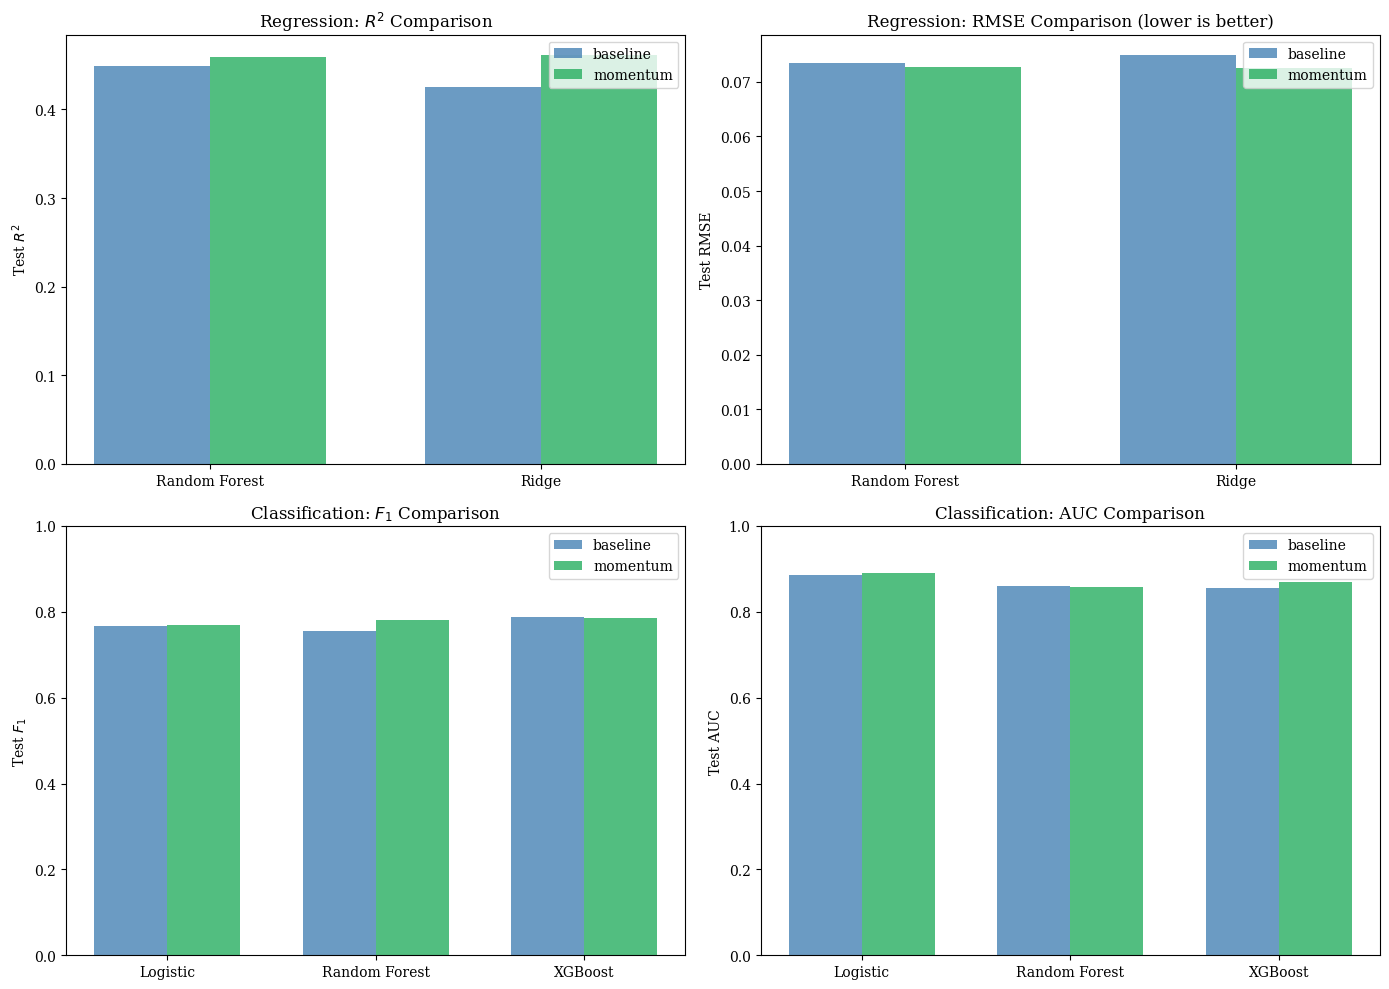

In [11]:
# Visualization: Side-by-side bar charts
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Regression R²
ax = axes[0, 0]
x = np.arange(len(reg_pivot))
width = 0.35
ax.bar(x - width/2, reg_pivot['baseline_Test_R2'], width, label='baseline', color='steelblue', alpha=0.8)
ax.bar(x + width/2, reg_pivot['momentum_Test_R2'], width, label='momentum', color='#27ae60', alpha=0.8)
ax.set_ylabel(r'Test $R^2$')
ax.set_title(r'Regression: $R^2$ Comparison')
ax.set_xticks(x)
ax.set_xticklabels(reg_pivot['Model'])
ax.legend()
ax.axhline(0, color='black', linewidth=0.5)

# Regression RMSE
ax = axes[0, 1]
ax.bar(x - width/2, reg_pivot['baseline_Test_RMSE'], width, label='baseline', color='steelblue', alpha=0.8)
ax.bar(x + width/2, reg_pivot['momentum_Test_RMSE'], width, label='momentum', color='#27ae60', alpha=0.8)
ax.set_ylabel(r'Test RMSE')
ax.set_title(r'Regression: RMSE Comparison (lower is better)')
ax.set_xticks(x)
ax.set_xticklabels(reg_pivot['Model'])
ax.legend()

# Classification F1
ax = axes[1, 0]
x = np.arange(len(clf_pivot))
ax.bar(x - width/2, clf_pivot['baseline_Test_F1'], width, label='baseline', color='steelblue', alpha=0.8)
ax.bar(x + width/2, clf_pivot['momentum_Test_F1'], width, label='momentum', color='#27ae60', alpha=0.8)
ax.set_ylabel(r'Test $F_1$')
ax.set_title(r'Classification: $F_1$ Comparison')
ax.set_xticks(x)
ax.set_xticklabels(clf_pivot['Model'])
ax.legend()
ax.set_ylim(0, 1)

# Classification AUC
ax = axes[1, 1]
ax.bar(x - width/2, clf_pivot['baseline_Test_AUC'], width, label='baseline', color='steelblue', alpha=0.8)
ax.bar(x + width/2, clf_pivot['momentum_Test_AUC'], width, label='momentum', color='#27ae60', alpha=0.8)
ax.set_ylabel(r'Test AUC')
ax.set_title(r'Classification: AUC Comparison')
ax.set_xticks(x)
ax.set_xticklabels(clf_pivot['Model'])
ax.legend()
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

## 5. Feature Importance Analysis

In [12]:
# Train final RF model with momentum to check feature importance
X_train_reg = df_clean.loc[train_mask, reg_features_momentum].values
rf_final = RandomForestRegressor(n_estimators=100, max_depth=10, min_samples_leaf=5, random_state=42, n_jobs=-1)
rf_final.fit(X_train_reg, y_train_reg)

# Feature importance
importance_df = pd.DataFrame({
    'Feature': reg_features_momentum,
    'Importance': rf_final.feature_importances_
}).sort_values('Importance', ascending=False)

print("Feature Importance (RF Regression with momentum):")
print("-" * 50)
for _, row in importance_df.head(10).iterrows():
    print(f"  {row['Feature']:<25} {row['Importance']:.4f}")

# Highlight momentum feature
gradient_importance = importance_df[importance_df['Feature'] == 'delay_rate_gradient']['Importance'].values[0]
gradient_rank = importance_df[importance_df['Feature'] == 'delay_rate_gradient'].index[0] + 1
print(f"\ndelay_rate_gradient rank: {gradient_rank} (importance: {gradient_importance:.4f})")

Feature Importance (RF Regression with momentum):
--------------------------------------------------
  delay_rate_lag1           0.5965
  sectors_scheduled         0.1041
  rainy_days_arr_exp        0.0854
  delay_rate_gradient       0.0667
  month_sin                 0.0622
  month_cos                 0.0512
  airline_Jetstar           0.0182
  airline_Tigerair Australia 0.0123
  airline_Virgin Australia  0.0025
  airline_Qantas            0.0007

delay_rate_gradient rank: 13 (importance: 0.0667)


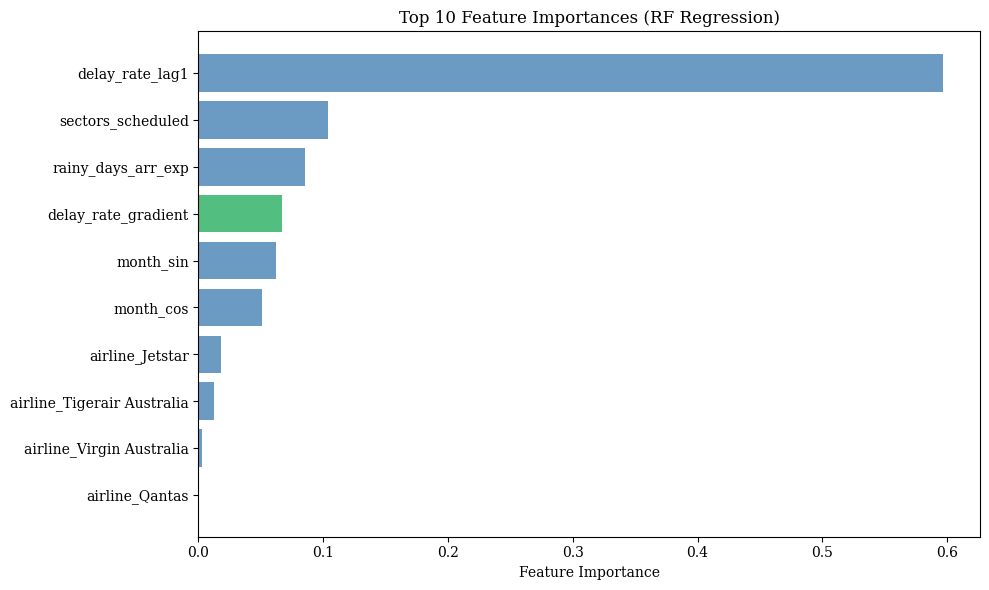

In [13]:
# Visualize top features
fig, ax = plt.subplots(figsize=(10, 6))

top_features = importance_df.head(10)
colors = ['#27ae60' if f == 'delay_rate_gradient' else 'steelblue' for f in top_features['Feature']]

ax.barh(top_features['Feature'], top_features['Importance'], color=colors, alpha=0.8)
ax.set_xlabel('Feature Importance')
ax.set_title('Top 10 Feature Importances (RF Regression)')
ax.invert_yaxis()

plt.tight_layout()
plt.show()

## 6. Current Performance: Actual vs Predicted (Ridge Regression)

In [ ]:
# Time-series comparison: Actual vs Predicted delay_rate (Ridge with momentum)
# Train on train set, predict on FULL dataset to see overall fit

X_train_ridge = df_clean.loc[train_mask, reg_features_momentum].values
X_all = df_clean[reg_features_momentum].values

scaler_ridge = StandardScaler()
X_train_ridge_scaled = scaler_ridge.fit_transform(X_train_ridge)
X_all_scaled = scaler_ridge.transform(X_all)

ridge_momentum = Ridge(alpha=1.0)
ridge_momentum.fit(X_train_ridge_scaled, y_train_reg)
all_predictions = ridge_momentum.predict(X_all_scaled)

# Create dataframe with all predictions - keep df_clean's index for proper mask alignment
full_df = df_clean[['year_month_dt', 'year', 'airline', 'departing_port', 'arriving_port', 'delay_rate']].copy()
full_df['predicted'] = all_predictions

# Mark train/val/test splits BEFORE sorting (masks are aligned with df_clean's index)
full_df['split'] = 'excluded'  # COVID period
full_df.loc[train_mask, 'split'] = 'train'
full_df.loc[val_mask, 'split'] = 'val'
full_df.loc[test_mask, 'split'] = 'test'

# Now sort for time-series plotting
full_df = full_df.sort_values('year_month_dt')

# Aggregate by month (average across airlines and routes)
monthly_agg = full_df.groupby('year_month_dt').agg({
    'delay_rate': 'mean',
    'predicted': 'mean',
    'split': 'first'
}).reset_index()

# Plot time-series comparison
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Full time series with train/val/test regions highlighted
ax = axes[0]

# Plot actual and predicted
ax.plot(monthly_agg['year_month_dt'], monthly_agg['delay_rate'], 'o-', 
        label='Actual', color='steelblue', linewidth=1.5, markersize=4, alpha=0.8)
ax.plot(monthly_agg['year_month_dt'], monthly_agg['predicted'], 's-', 
        label='Predicted (Ridge)', color='#e74c3c', linewidth=1.5, markersize=4, alpha=0.8)

# Shade regions by split
train_months = monthly_agg[monthly_agg['split'] == 'train']['year_month_dt']
val_months = monthly_agg[monthly_agg['split'] == 'val']['year_month_dt']
test_months = monthly_agg[monthly_agg['split'] == 'test']['year_month_dt']
excluded_months = monthly_agg[monthly_agg['split'] == 'excluded']['year_month_dt']

if len(excluded_months) > 0:
    ax.axvspan(excluded_months.min(), excluded_months.max(), alpha=0.15, color='gray', label='COVID excluded')

ax.axhline(0.25, color='orange', linestyle=':', linewidth=1.5, label='High delay threshold (25%)')
ax.set_xlabel('Month')
ax.set_ylabel('Delay Rate')
ax.set_title('Full Dataset: Actual vs Predicted Delay Rate (Monthly Average, All Airlines)')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)

# Plot 2: Scatter plot of actual vs predicted by split
ax = axes[1]

split_colors = {'train': 'steelblue', 'val': '#27ae60', 'test': '#e74c3c', 'excluded': 'gray'}
split_labels = {'train': 'Train (2010-17, 2024)', 'val': 'Val (2018, 2023)', 
                'test': 'Test (2019, 2025)', 'excluded': 'COVID (2020-22)'}

for split_name in ['train', 'val', 'test', 'excluded']:
    split_data = full_df[full_df['split'] == split_name]
    if len(split_data) > 0:
        ax.scatter(split_data['delay_rate'], split_data['predicted'], 
                   alpha=0.4, s=20, c=split_colors[split_name], label=split_labels[split_name])

# Perfect prediction line
ax.plot([0, 0.8], [0, 0.8], 'k--', linewidth=1, label='Perfect prediction')
ax.set_xlabel('Actual Delay Rate')
ax.set_ylabel('Predicted Delay Rate')
ax.set_title('Actual vs Predicted: All Data Points by Split')
ax.legend(loc='upper left', fontsize=9)
ax.set_xlim(0, 0.8)
ax.set_ylim(0, 0.8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics by split using sklearn's r2_score for consistency
print("\nPrediction Summary by Split (Ridge with momentum):")
print("-" * 60)
for split_name in ['train', 'val', 'test', 'excluded']:
    split_data = full_df[full_df['split'] == split_name]
    if len(split_data) > 0:
        mae = np.abs(split_data['delay_rate'] - split_data['predicted']).mean()
        corr = split_data['delay_rate'].corr(split_data['predicted'])
        r2 = r2_score(split_data['delay_rate'], split_data['predicted'])
        print(f"  {split_labels[split_name]:<25} MAE={mae:.4f}, R²={r2:.4f}, Corr={corr:.4f}")
        

SUMMARY: Impact of delay_rate_gradient (momentum feature)

REGRESSION MODELS:
--------------------------------------------------
  Random Forest: R² +0.0104, RMSE -0.0007 → IMPROVED
  Ridge: R² +0.0356, RMSE -0.0024 → IMPROVED

CLASSIFICATION MODELS:
--------------------------------------------------
  Logistic: F1 +0.0028, AUC +0.0054 → NO CHANGE
  Random Forest: F1 +0.0278, AUC -0.0006 → IMPROVED
  XGBoost: F1 -0.0024, AUC +0.0123 → NO CHANGE

RECOMMENDATION

RECOMMEND: Include delay_rate_gradient (momentum feature)
  - Improved 3/5 models


## 7. Summary and Recommendations

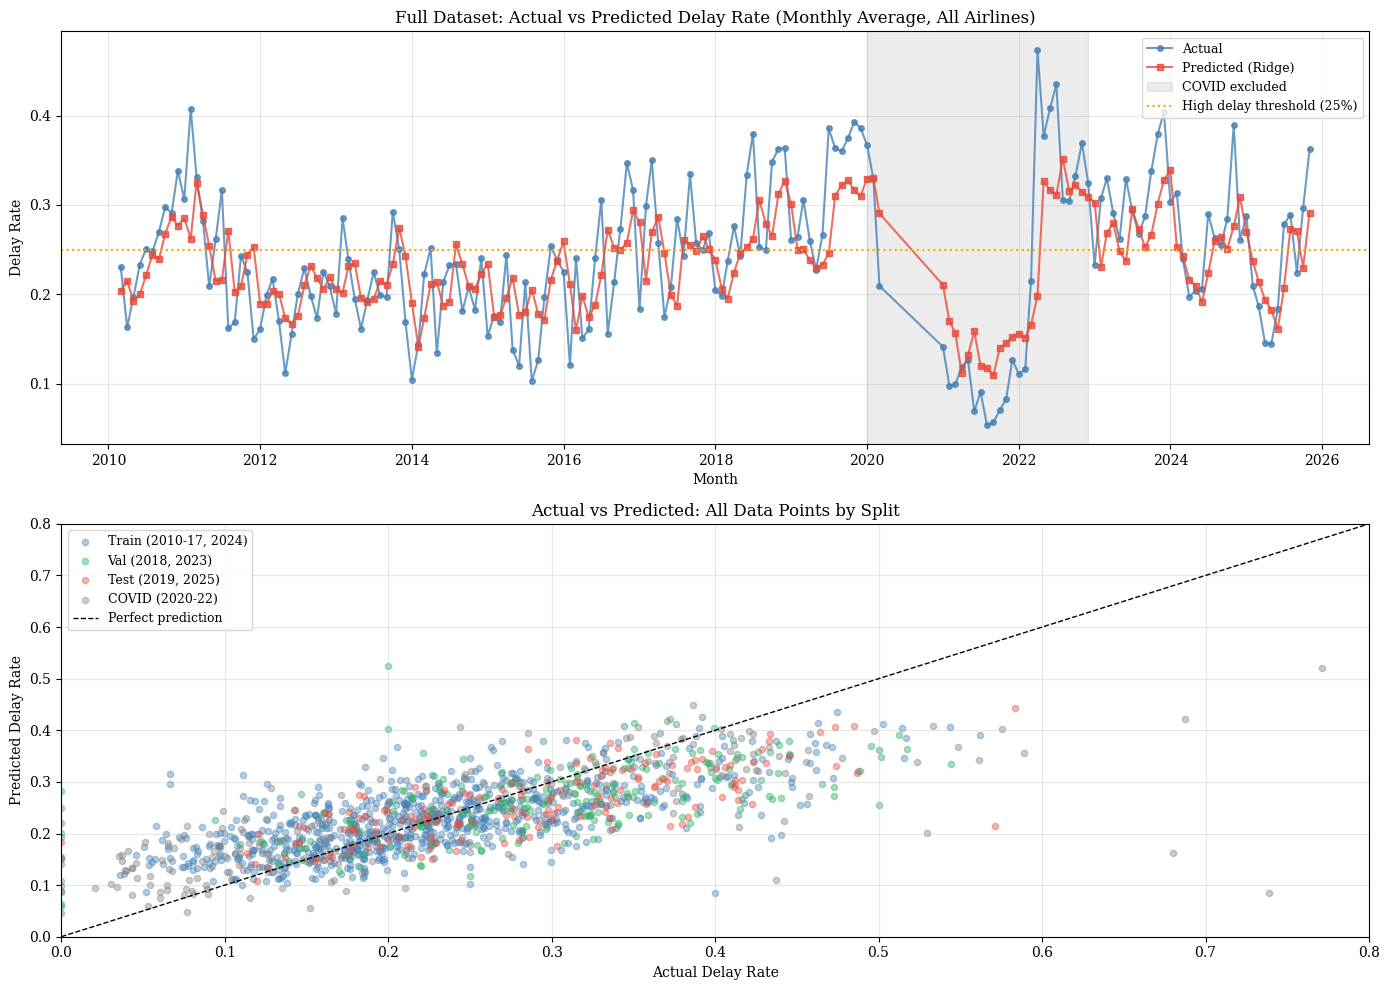


Prediction Summary by Split (Ridge with momentum):
------------------------------------------------------------
  Train (2010-17, 2024)     MAE=0.0521, R²=0.4709, Corr=0.6862
  Val (2018, 2023)          MAE=0.0669, R²=0.2973, Corr=0.6214
  Test (2019, 2025)         MAE=0.0552, R²=0.4614, Corr=0.7453
  COVID (2020-22)           MAE=0.0744, R²=0.5646, Corr=0.7616


In [ ]:
# Summary
print("=" * 80)
print("SUMMARY: Impact of delay_rate_gradient (momentum feature)")
print("=" * 80)

print("\nREGRESSION MODELS:")
print("-" * 50)
for _, row in reg_pivot.iterrows():
    model = row['Model']
    r2_diff = row['R2_diff']
    rmse_diff = row['RMSE_diff']
    
    if r2_diff > 0.005:
        verdict = "IMPROVED"
    elif r2_diff < -0.005:
        verdict = "WORSE"
    else:
        verdict = "NO CHANGE"
    
    print(f"  {model}: R² {r2_diff:+.4f}, RMSE {rmse_diff:+.4f} → {verdict}")

print("\nCLASSIFICATION MODELS:")
print("-" * 50)
for _, row in clf_pivot.iterrows():
    model = row['Model']
    f1_diff = row['F1_diff']
    auc_diff = row['AUC_diff']
    
    if f1_diff > 0.005:
        verdict = "IMPROVED"
    elif f1_diff < -0.005:
        verdict = "WORSE"
    else:
        verdict = "NO CHANGE"
    
    print(f"  {model}: F1 {f1_diff:+.4f}, AUC {auc_diff:+.4f} → {verdict}")

# Overall recommendation
print("\n" + "=" * 80)
print("RECOMMENDATION")
print("=" * 80)

# Count improvements
reg_improved = (reg_pivot['R2_diff'] > 0.005).sum()
reg_worse = (reg_pivot['R2_diff'] < -0.005).sum()
clf_improved = (clf_pivot['F1_diff'] > 0.005).sum()
clf_worse = (clf_pivot['F1_diff'] < -0.005).sum()

total_improved = reg_improved + clf_improved
total_worse = reg_worse + clf_worse
total_models = len(reg_pivot) + len(clf_pivot)

if total_improved > total_worse:
    print(f"\nRECOMMEND: Include delay_rate_gradient (momentum feature)")
    print(f"  - Improved {total_improved}/{total_models} models")
elif total_worse > total_improved:
    print(f"\nRECOMMEND: Do NOT include delay_rate_gradient")
    print(f"  - Worsened {total_worse}/{total_models} models")
else:
    print(f"\nMixed results - momentum feature has minimal impact")
    print(f"  - Consider keeping for interpretability if momentum/trend matters")

### Observations
- TBD